# BF-BOF BAU steel NPV simulation

Run the Monte Carlo simulation for BF-BOF BAU steel and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "bf_bof_bau"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tcs,present_value_total_cost_eur,lcos_eur_per_tcs,levelized_net_margin_eur_per_tcs
0,0,bf_bof_bau,absolute,not_applicable,1000000.0,20.0,654.092835,42.633007,307.300117,pci_coking_coal_mix,...,7.613505e+06,0.0,1.467435e+08,6.338298e+08,1.161702e+08,4.864838e+08,9.818147e+06,6.877127e+09,700.450553,49.549447
1,1,bf_bof_bau,absolute,not_applicable,1000000.0,20.0,642.370111,45.668276,329.286808,pci_coking_coal_mix,...,1.036622e+07,0.0,1.440067e+08,6.574861e+08,9.251385e+07,2.659445e+08,9.818147e+06,7.097666e+09,722.912964,27.087036
2,2,bf_bof_bau,absolute,not_applicable,1000000.0,20.0,632.863456,42.114726,290.184429,pci_coking_coal_mix,...,1.428285e+07,0.0,1.466743e+08,6.217344e+08,1.282656e+08,6.264670e+08,9.818147e+06,6.737144e+09,686.192949,63.807051
3,3,bf_bof_bau,absolute,not_applicable,1000000.0,20.0,515.181093,40.695206,304.646539,pci_coking_coal_mix,...,1.447670e+07,0.0,1.461919e+08,6.338505e+08,1.161495e+08,6.251921e+08,9.818147e+06,6.738418e+09,686.322802,63.677198
4,4,bf_bof_bau,absolute,not_applicable,1000000.0,20.0,505.002040,45.373251,315.174042,pci_coking_coal_mix,...,1.242101e+07,0.0,1.433601e+08,6.448470e+08,1.051530e+08,5.274054e+08,9.818147e+06,6.836205e+09,696.282593,53.717407


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,447.004082,704.471647,45.528353
std,170.871253,17.403615,17.403615
min,-6.585323,642.458204,-0.670730
5%,195.500604,673.118332,19.912168
50%,427.923670,706.415029,43.584971
95%,754.835551,730.087832,76.881668
max,1055.861202,750.670730,107.541796


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),99997,0.99997
1,Negative (NPV < 0),3,0.00003


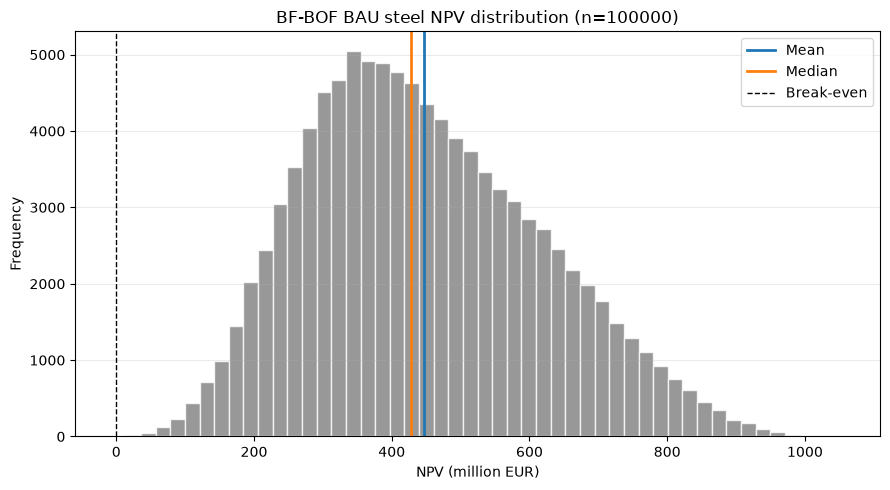

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"BF-BOF BAU steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


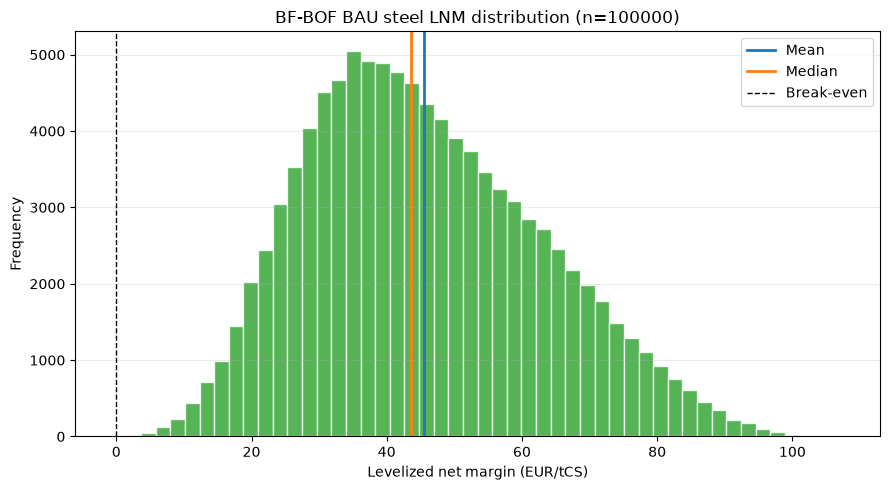

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"BF-BOF BAU steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


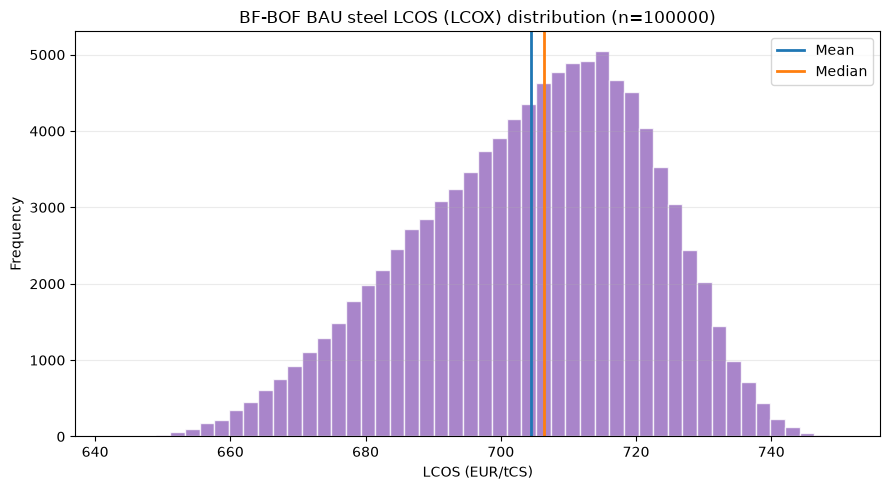

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"BF-BOF BAU steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             750.000000
annual_fixed_opex_eur           43.001845
annual_variable_opex_eur       313.294691
annual_fuel_cost_eur           128.496572
annual_electricity_cost_eur     13.406257
annual_emissions_cost_eur      145.598075
annual_net_cash_flow_eur       106.202561
Name: Mean annual value, million EUR, dtype: float64